In [18]:
from sklearn.datasets import load_digits
import numpy as np

digits = load_digits()

print("Dataset keys:", digits.keys())
print("\nData shape:", digits.data.shape)
print("Images shape:", digits.images.shape)
print("Labels shape:", digits.target.shape)
print("\nUnique classes:", np.unique(digits.target))
print("Total samples:", len(digits.data))

Dataset keys: dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

Data shape: (1797, 64)
Images shape: (1797, 8, 8)
Labels shape: (1797,)

Unique classes: [0 1 2 3 4 5 6 7 8 9]
Total samples: 1797


# Visualizing the Data

**Graph 1: Display actual digit images**

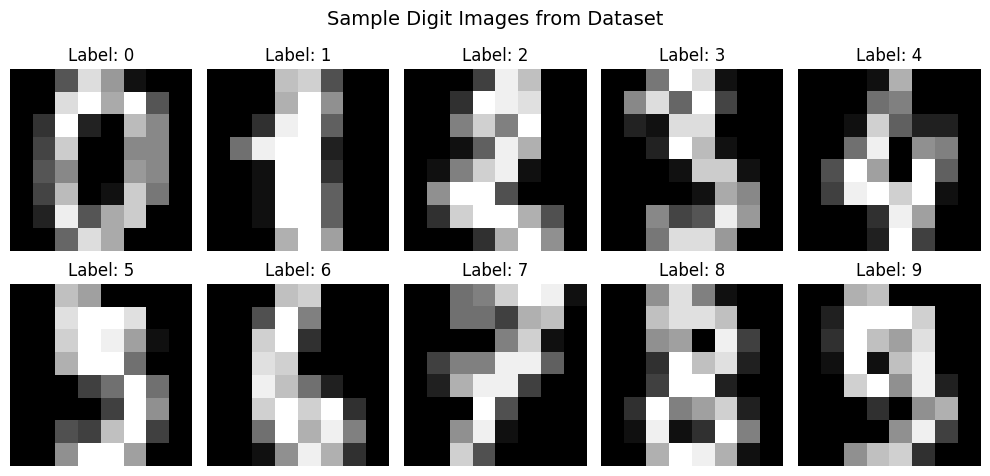

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(digits.images[i], cmap='gray')
    axes[i].set_title(f"Label: {digits.target[i]}")
    axes[i].axis('off')

plt.suptitle("Sample Digit Images from Dataset", fontsize=14)
plt.tight_layout()
plt.show()

**Graph 2: Class Distribution (Bar Chart)**

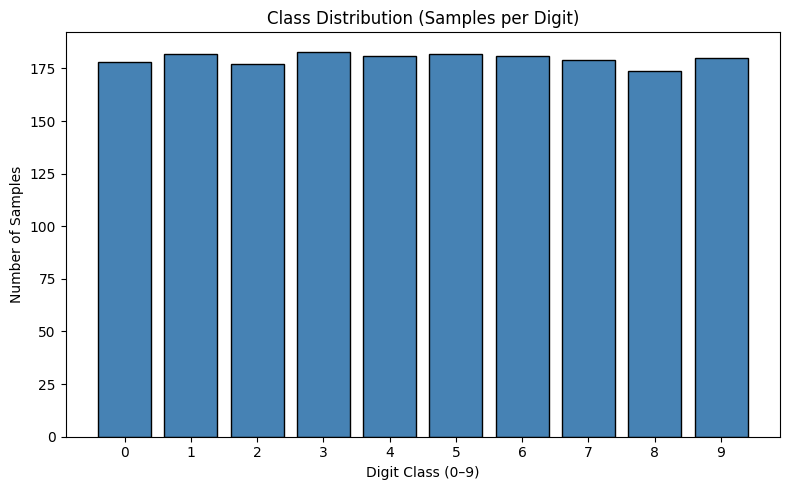

Samples per class:
  Digit 0: 178 samples
  Digit 1: 182 samples
  Digit 2: 177 samples
  Digit 3: 183 samples
  Digit 4: 181 samples
  Digit 5: 182 samples
  Digit 6: 181 samples
  Digit 7: 179 samples
  Digit 8: 174 samples
  Digit 9: 180 samples


In [20]:
import pandas as pd

# Count how many samples exist per digit
unique, counts = np.unique(digits.target, return_counts=True)

plt.figure(figsize=(8, 5))
plt.bar(unique, counts, color='steelblue', edgecolor='black')
plt.title("Class Distribution (Samples per Digit)")
plt.xlabel("Digit Class (0–9)")
plt.ylabel("Number of Samples")
plt.xticks(unique)
plt.tight_layout()
plt.show()

print("Samples per class:")
for u, c in zip(unique, counts):
    print(f"  Digit {u}: {c} samples")

**Graph 3: Pixel Intensity Histogram**

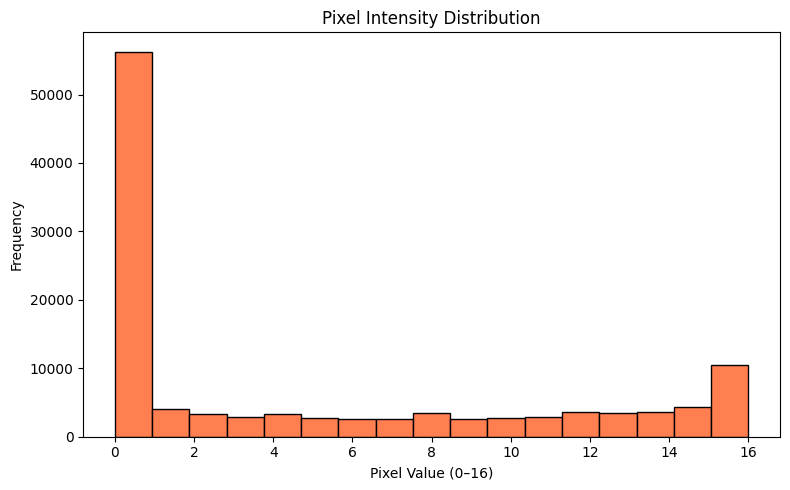

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(digits.data.flatten(), bins=17, color='coral', edgecolor='black')
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value (0–16)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Data Preprocessing

Normalize the Data

In [22]:
X = digits.data / 16.0
y = digits.target

print("Before normalization - Min:", digits.data.min(), "Max:", digits.data.max())
print("After normalization  - Min:", X.min(), "Max:", X.max())

Before normalization - Min: 0.0 Max: 16.0
After normalization  - Min: 0.0 Max: 1.0


Train/Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])
print("Input features:  ", X_train.shape[1])

Training samples: 1437
Testing samples:  360
Input features:   64


# Building the ANN Model

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(128, activation='relu', input_shape=(64,)),
    Dense(64,  activation='relu'),
    Dense(10,  activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,226 (67.29 KB)

 Trainable params: 17,226 (67.29 KB)

 Non-trainable params: 0 (0.00 B)

# Training the model

In [25]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5963 - loss: 1.7908 - val_accuracy: 0.8819 - val_loss: 1.2075
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8739 - loss: 0.8393 - val_accuracy: 0.9028 - val_loss: 0.5019
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9157 - loss: 0.4125 - val_accuracy: 0.9375 - val_loss: 0.2951
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9358 - loss: 0.2739 - val_accuracy: 0.9444 - val_loss: 0.2139
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9490 - loss: 0.2038 - val_accuracy: 0.9375 - val_loss: 0.2332
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9652 - loss: 0.1679 - val_accuracy: 0.9306 - val_loss: 0.1860
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9652 - loss: 0.1447 - val_accuracy: 0.9375 - val_loss: 0.1685
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9729 - loss: 0.1196 - val_accuracy: 0.9583 - val_loss:

Learning Curve

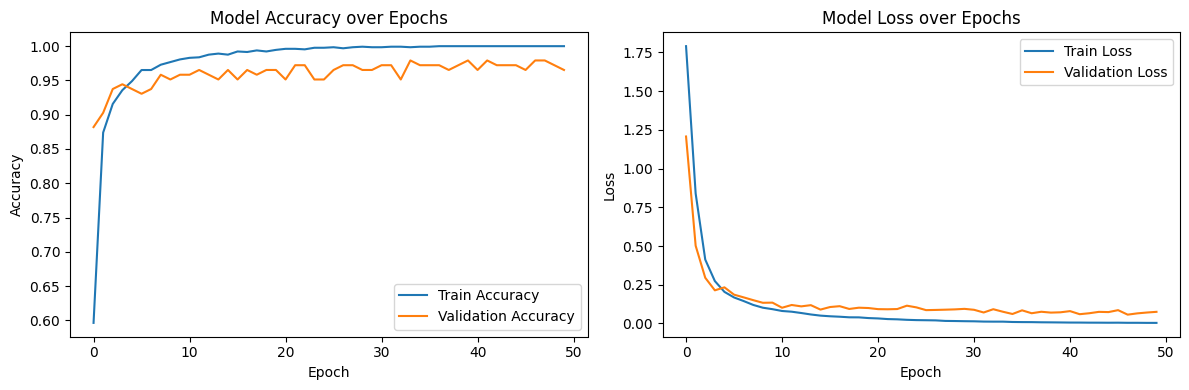

In [26]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Step 6: Model Evaluation

Accuracy Score

In [27]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

Test Accuracy: 97.50%
Test Loss:     0.0988


Confusion Matrix

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


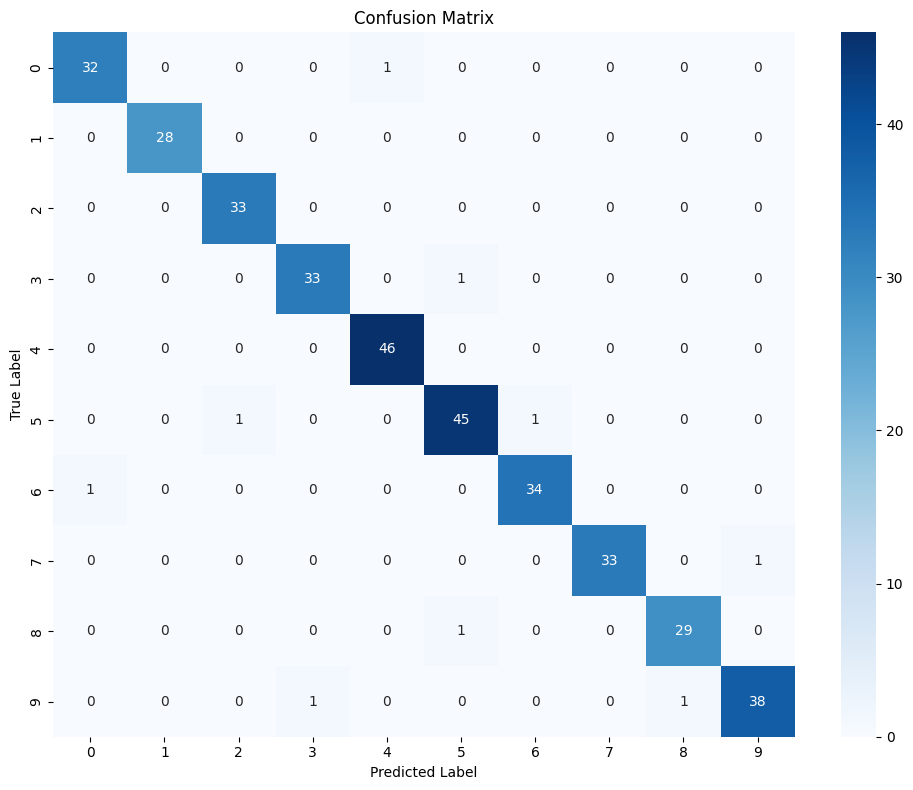

In [28]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10),
            yticklabels=range(10))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

Precision, Recall and Full Report

In [29]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        33
           1       1.00      1.00      1.00        28
           2       0.97      1.00      0.99        33
           3       0.97      0.97      0.97        34
           4       0.98      1.00      0.99        46
           5       0.96      0.96      0.96        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.97      0.95      0.96        40

    accuracy                           0.97       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.97      0.97       360



# Interactive Digit Predictor

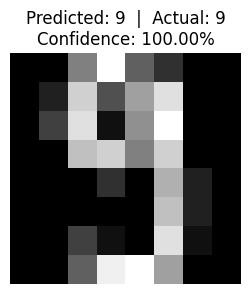

Predicted Digit : 9
Actual Digit    : 9
Confidence      : 100.00%
Correct         : True


In [35]:
def predict_digit(index):
    image = X_test[index]
    actual_label = y_test[index]

    image_input = image.reshape(1, -1)

    prediction_probs = model.predict(image_input, verbose=0)
    predicted_label = np.argmax(prediction_probs)
    confidence = np.max(prediction_probs) * 100

    plt.figure(figsize=(3, 3))
    plt.imshow(image.reshape(8, 8), cmap='gray')
    plt.title(f"Predicted: {predicted_label}  |  Actual: {actual_label}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

    print(f"Predicted Digit : {predicted_label}")
    print(f"Actual Digit    : {actual_label}")
    print(f"Confidence      : {confidence:.2f}%")
    print(f"Correct         : {predicted_label == actual_label}")

predict_digit(36)

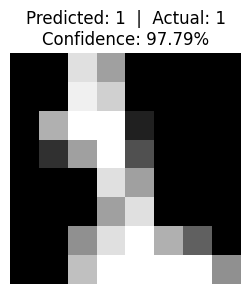

Predicted Digit : 1
Actual Digit    : 1
Confidence      : 97.79%
Correct         : True


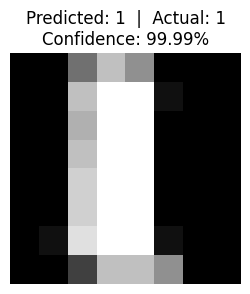

Predicted Digit : 1
Actual Digit    : 1
Confidence      : 99.99%
Correct         : True


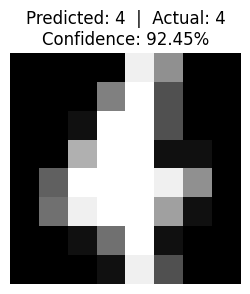

Predicted Digit : 4
Actual Digit    : 4
Confidence      : 92.45%
Correct         : True


In [36]:
predict_digit(5)
predict_digit(42)
predict_digit(100)

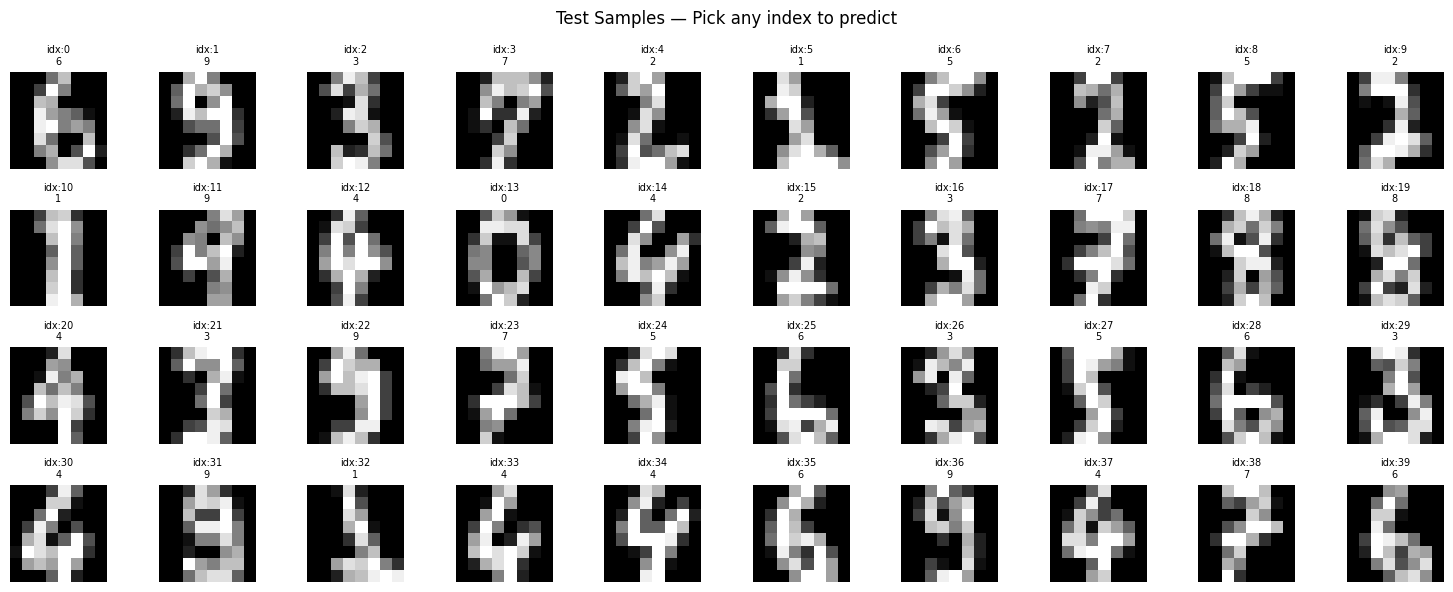

In [39]:
fig, axes = plt.subplots(4, 10, figsize=(15, 6))
axes = axes.flatten()

for i in range(40):
    axes[i].imshow(X_test[i].reshape(8, 8), cmap='gray')
    axes[i].set_title(f"idx:{i}\n{y_test[i]}", fontsize=7)
    axes[i].axis('off')

plt.suptitle("Test Samples — Pick any index to predict", fontsize=12)
plt.tight_layout()
plt.show()